In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

Current working directory:
c:\Users\ttnkashe\Documents\recurrent-staged-loras\notebooks


In [3]:
from pathlib import Path

for p in Path(".").glob("**/metrics.json"):
    print(p)

In [4]:
RUNS = {
    "Base": "../outputs/base/base_seed11/metrics.json",
    "Standard LoRA": "../outputs/standard_lora/standard_lora_seed11/metrics.json",
    "Shared Recurrence": "../outputs/shared_recurrence/shared_recurrence_seed11/metrics.json",
    "Stage-Specialized": "../outputs/stage_specialized_recurrence/stage_specialized_recurrence_seed11/metrics.json",
}

metrics = {}

for name, path in RUNS.items():
    path = Path(path)
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            metrics[name] = json.load(f)
    else:
        print(f"Missing: {path}")

metrics.keys()

dict_keys(['Base', 'Standard LoRA', 'Shared Recurrence', 'Stage-Specialized'])

In [8]:
df.columns

Index(['Model', 'Train Loss', 'Eval Loss', 'Eval PPL', 'Stage 2 Acc',
       'Stage 3 Acc', 'Trainable Params', 'Steps', 'Final Answer Acc'],
      dtype='object')

In [7]:
rows = []

for name, m in metrics.items():
    rows.append({
        "Model": name,
        "Train Loss": m.get("final_train_loss"),
        "Eval Loss": m.get("final_eval_loss"),
        "Eval PPL": m.get("eval_perplexity"),
        "Stage 2 Acc": m.get("stage_2_token_accuracy"),
        "Stage 3 Acc": m.get("stage_3_token_accuracy"),
        "Trainable Params": m.get("trainable_params"),
        "Steps": m.get("global_steps_completed"),
        "Final Answer Acc": m.get("final_answer_accuracy"),
    })

df = pd.DataFrame(rows)
df

,Model,Train Loss,Eval Loss,Eval PPL,Stage 2 Acc,Stage 3 Acc,Trainable Params,Steps,Final Answer Acc
0,Base,0.982129,0.964050,2.622296,0.881545,0.611239,0,2000,0.007959
1,Standard LoRA,0.369015,0.369087,1.446414,0.936787,0.997169,43646976,2000,0.988061
2,Shared Recurrence,1.009293,1.353158,3.869627,0.846491,0.884043,33628160,2000,0.404775
3,Stage-Specialized,1.018180,1.448782,4.257927,0.834752,0.897777,33759232,2000,0.518476


In [9]:
df.sort_values(
    by="Final Answer Acc",
    ascending=False
)

,Model,Train Loss,Eval Loss,Eval PPL,Stage 2 Acc,Stage 3 Acc,Trainable Params,Steps,Final Answer Acc
1,Standard LoRA,0.369015,0.369087,1.446414,0.936787,0.997169,43646976,2000,0.988061
3,Stage-Specialized,1.018180,1.448782,4.257927,0.834752,0.897777,33759232,2000,0.518476
2,Shared Recurrence,1.009293,1.353158,3.869627,0.846491,0.884043,33628160,2000,0.404775
0,Base,0.982129,0.964050,2.622296,0.881545,0.611239,0,2000,0.007959


## Initial Observations

- Standard LoRA achieved the strongest overall performance across all metrics.
- Stage-Specialized Recurrence outperformed Shared Recurrence on final-answer accuracy and Stage 3 token accuracy.
- Both recurrence variants substantially improved over the frozen-base condition.
- The recurrence approaches used fewer trainable parameters than Standard LoRA but did not match its performance in this configuration.

In [21]:
print(metrics.keys())

dict_keys(['Base', 'Standard LoRA', 'Shared Recurrence', 'Stage-Specialized'])


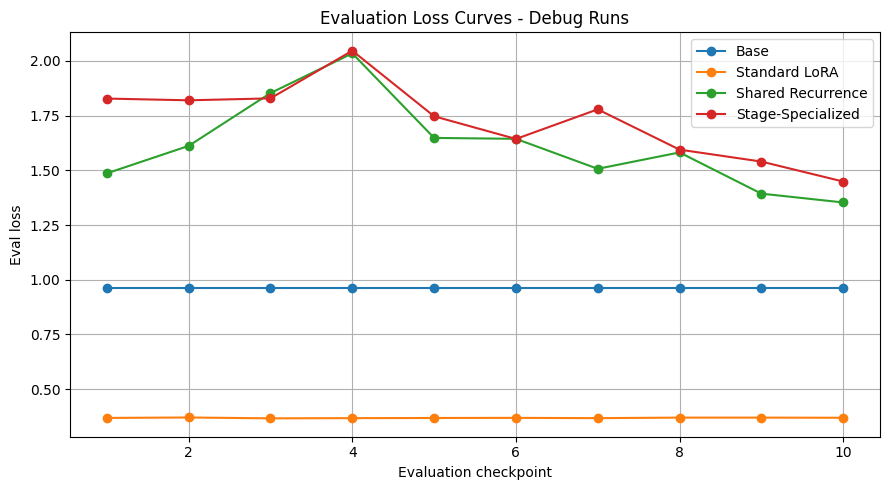

In [22]:
plt.figure(figsize=(9, 5))

for name, m in metrics.items():
    losses = m.get("eval_loss_history", [])
    if losses:
        plt.plot(range(1, len(losses) + 1), losses, marker="o", label=name)

plt.title("Evaluation Loss Curves - Debug Runs")
plt.xlabel("Evaluation checkpoint")
plt.ylabel("Eval loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

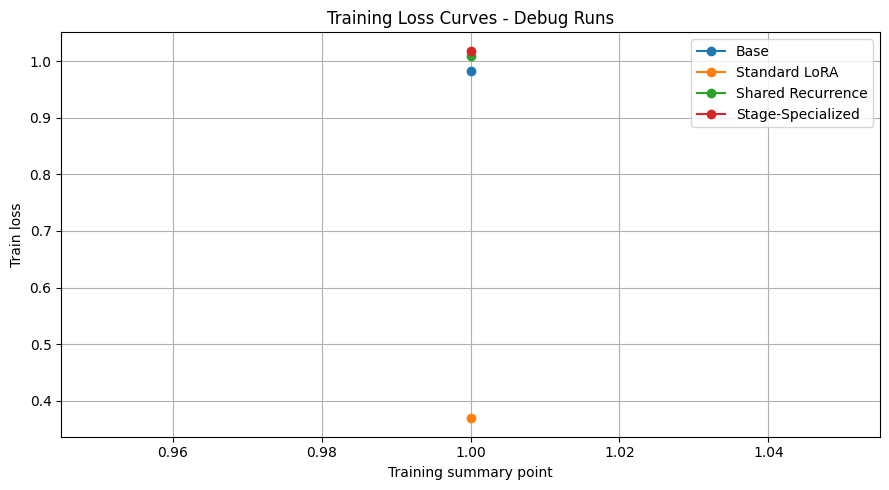

In [23]:
plt.figure(figsize=(9, 5))

for name, m in metrics.items():
    losses = m.get("train_loss_history", [])
    if losses:
        plt.plot(range(1, len(losses) + 1), losses, marker="o", label=name)

plt.title("Training Loss Curves - Debug Runs")
plt.xlabel("Training summary point")
plt.ylabel("Train loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

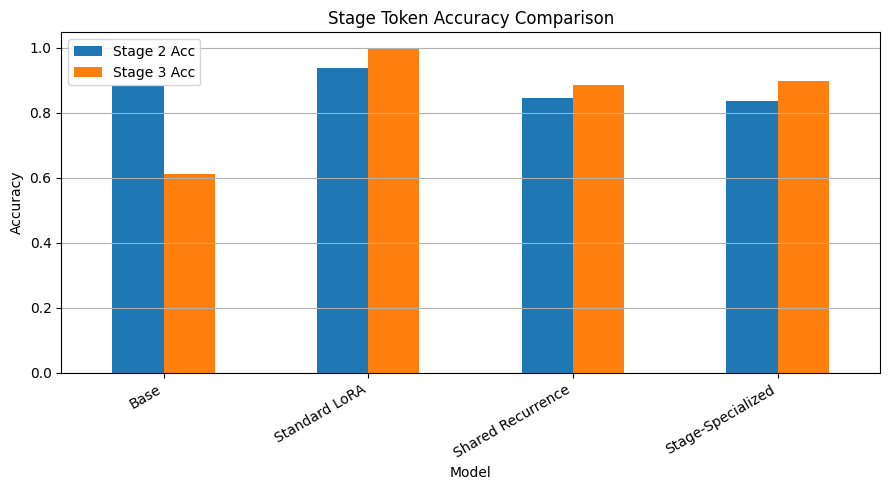

In [24]:
df_plot = df.set_index("Model")[["Stage 2 Acc", "Stage 3 Acc"]]

df_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Stage Token Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

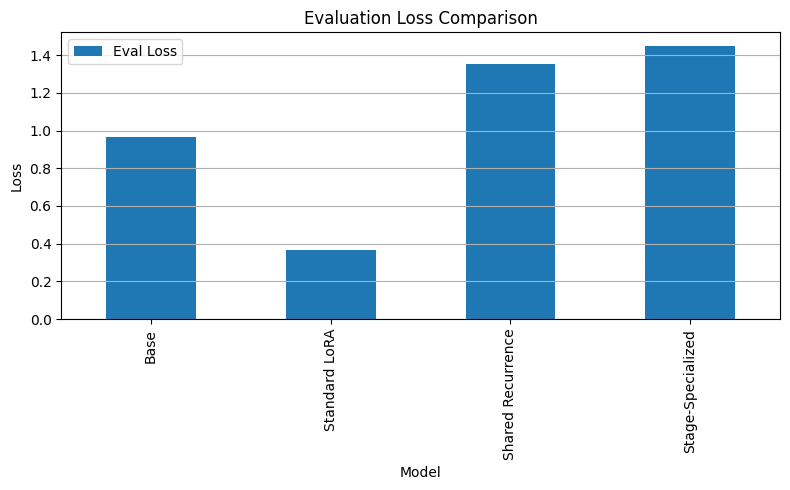

In [25]:
df_plot = df.set_index("Model")[["Eval Loss"]]

ax = df_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Evaluation Loss Comparison")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.tight_layout()
plt.show()